<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_BigData26/blob/main/Praktikum1/BD_A_T01_2411531002_SaskiaAlifah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS_BD_A_P01_2411531002_SaskiaAlifah



## Persiapan Lingkungan

Konvensi notebook sama seperti Praktikum 1: setiap langkah berupa satu sel teks (judul + penjelasan singkat), satu sel kode, ditutup satu sel teks berisi interpretasi berdasarkan **angka nyata dari eksekusi di bawah**.

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.35
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 18.1.0
matplotlib : 3.10.0


In [ ]:
!free -h         # kapasitas dan sisa RAM
!df -h /content 2>/dev/null || df -h .   # kapasitas dan sisa disk runtime
!java -version    # dibutuhkan PySpark

               total        used        free      shared  buff/cache   available
Mem:            12Gi       638Mi       8.9Gi       2.0Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.024s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.024s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharing)


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1/Tugas"
    DIR_KERJA  = "/content/data"
except ModuleNotFoundError:
    print("Bukan lingkungan Colab -> memakai folder lokal sebagai pengganti Google Drive.")
    DIR_SIMPAN = "./drive_MyDrive_BigData_Praktikum1_Tugas"
    DIR_KERJA  = "./data"

import os
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print("DIR_KERJA :", DIR_KERJA)
print("DIR_SIMPAN:", DIR_SIMPAN)

Mounted at /content/drive
DIR_KERJA : /content/data
DIR_SIMPAN: /content/drive/MyDrive/BigData/Praktikum1/Tugas


In [ ]:
import time, os, psutil

proses  = psutil.Process(os.getpid())
catatan = []          # menyimpan hasil pengukuran (bulan Juli) untuk pengukuran_kinerja.csv

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori RSS."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

## Bagian 1 — Ganti Dataset (mengulangi J-4 s.d. J-10 untuk Juli 2023)

### J-4. Mengunduh dataset dan inspeksi awal, termasuk pemeriksaan skema

Dataset tugas: **NYC TLC Yellow Taxi Trip Records bulan Juli 2023** (`yellow_tripdata_2023-07.parquet`). File hanya diunduh jika belum ada di `DIR_KERJA`. Sebelum menyamakan daftar kolom dengan Praktikum 1, skema kedua file diperiksa lebih dulu lewat metadata Parquet — **tanpa memuat satu baris pun** — sesuai instruksi modul.

In [ ]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-07.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))
else:
    print("File sudah tersedia, unduhan dilewati:", PATH)

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.87 s | RSS +1.5 MB
Ukuran file: 46.1 MB


In [ ]:
import pyarrow.parquet as pq

PATH_JAN = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
if not os.path.exists(PATH_JAN):
    URL_JAN = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
               "yellow_tripdata_2023-01.parquet")
    ukur("unduh dataset Januari (pembanding)", lambda: urllib.request.urlretrieve(URL_JAN, PATH_JAN))

meta_jul = pq.ParquetFile(PATH).metadata
meta_jan = pq.ParquetFile(PATH_JAN).metadata

kolom_jul = set(pq.ParquetFile(PATH).schema.names)
kolom_jan = set(pq.ParquetFile(PATH_JAN).schema.names)

print("=== Juli 2023 ===")
print("Jumlah baris :", f"{meta_jul.num_rows:,}")
print("Jumlah kolom :", meta_jul.num_columns)
print("Row group    :", meta_jul.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

print("\n=== Januari 2023 (Praktikum 1) ===")
print("Jumlah baris :", f"{meta_jan.num_rows:,}")
print("Jumlah kolom :", meta_jan.num_columns)

print("\nKolom yang berbeda antara Juli dan Januari:", kolom_jul.symmetric_difference(kolom_jan) or "(tidak ada)")

[unduh dataset Januari (pembanding)] 0.28 s | RSS +0.0 MB
=== Juli 2023 ===
Jumlah baris : 2,907,108
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

=== Januari 2023 (Praktikum 1) ===
Jumlah baris : 3,066,766
Jumlah kolom : 19

Kolom yang berbeda antara Juli dan Januari: {'Airport_fee', 'airport_fee'}


**Hasil pemeriksaan skema:** kedua file memiliki 19 kolom yang sama secara isi, tetapi terdapat **perbedaan penulisan pada satu nama kolom** — `Airport_fee` (Juli, huruf A besar) vs `airport_fee` (Januari, huruf a kecil). Kolom ini tidak termasuk dalam delapan kolom (`KOLOM`) yang dipakai pada praktikum ini, sehingga tidak berdampak pada langkah selanjutnya — namun ini membuktikan pentingnya instruksi modul untuk **selalu memeriksa metadata Parquet lebih dulu** sebelum menyamakan skema antar bulan, karena penerbit data bisa mengubah kapitalisasi nama kolom tanpa pemberitahuan formal.

### J-5. Memuat data dan mengukur biaya memorinya

Sama seperti Praktikum 1: memuat *semua* kolom lebih dulu, lalu memuat *hanya* delapan kolom yang dibutuhkan, dan membandingkan angkanya.

In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 0.96 s | RSS +495.8 MB
Dimensi: (2907108, 19)
Memori : 502.5 MB
[baca kolom terpilih] 0.35 s | RSS +201.2 MB
Dimensi: (2907108, 8)
Memori : 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2   # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB


,0
tpep_pickup_datetime,22.179474
payment_type,22.179474
tpep_dropoff_datetime,22.179474
passenger_count,22.179474
trip_distance,22.179474
tip_amount,22.179474
fare_amount,22.179474
total_amount,22.179474
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

177.4 MB -> 113.7 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


**Interpretasi:** angka penghematan memori tercetak langsung di output sel di atas. Pola sama seperti Praktikum 1 — kolom `payment_type` (dari `int64` menjadi `category`) tetap menjadi penyumbang penghematan proporsional terbesar per kolom, karena kardinalitasnya rendah (hanya beberapa kode pembayaran).

### J-6. Pemeriksaan kualitas data dan pembersihan (veracity)

*Threshold* yang dipakai sama persis dengan Praktikum 1 (jarak > 0 dan < 100 mil, durasi 1–180 menit, tarif > 0) agar kedua bulan dapat dibandingkan secara adil pada Bagian 2.

In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"       : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"      : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"]  > 180).sum(),
    "total_amount <= 0": (df["total_amount"]  <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,}, "
      f"{100*(len(df)-len(bersih))/len(df):.2f}%)")

2,907,108 baris -> 2,817,657 baris  (dibuang 89,451, 3.08%)


### J-7. Memproses file lebih besar dari memori dengan chunking

Data ditulis ulang sebagai CSV (jauh lebih besar tanpa kompresi), lalu diproses potongan demi potongan tanpa pernah dimuat penuh — persis pola *out-of-core* pada Praktikum 1.

In [ ]:
CSV = os.path.join(DIR_KERJA, "trips_juli.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 34.59 s | RSS +5.4 MB
Parquet: 46.1 MB
CSV    : 213.6 MB


In [ ]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 5.87 s | RSS +30.1 MB
2,817,657 baris | rata-rata total_amount = 29.04


**Interpretasi:** kolom `delta_rss_mb` pada hasil `ukur()` untuk langkah "agregasi chunking" tetap kecil meski memproses jutaan baris, karena hanya satu potongan (`chunksize=500_000`) berada di memori pada satu waktu — inti gagasan pemrosesan *out-of-core*, konsisten dengan temuan Praktikum 1.

### J-8. Pendekatan terdistribusi: PySpark local mode

Konfigurasi sama seperti Praktikum 1 — `local[*]`, `spark.sql.shuffle.partitions=8` (bukan default 200) karena data ini masih tergolong kecil untuk klaster.

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-Tugas-Juli")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 4.0.4


In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 3.19 s | RSS +0.0 MB
Jumlah baris: 2907108
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif

In [ ]:
sdf_bersih.createOrReplaceTempView("trips_juli")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                       AS jumlah,
           ROUND(AVG(total_amount), 2)    AS rata_tarif,
           ROUND(AVG(tip_amount), 2)      AS rata_tip
    FROM trips_juli
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()      # rencana eksekusi — perhatikan Exchange / HashAggregate
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2202049|     29.82|    4.36|
|           2| 512650|     25.54|     0.0|
|           0|  73668|     31.31|    3.59|
|           4|  19114|     27.03|    0.02|
|           3|  10176|     24.49|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#44 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#44 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=209]
      +- HashAggregate(keys=[jam#44], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#44, 8), ENSURE_REQUIREMENTS, [plan_id=206]
            +- HashAggregate(keys=[jam#44], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

**Interpretasi:** seperti pada Praktikum 1, `sdf.count()` memakan waktu jauh lebih lama dari dugaan awal karena Spark bersifat *lazy* — pekerjaan sesungguhnya baru dijalankan saat ada *action*. Untuk data satu bulan pada satu mesin tanpa klaster, agregasi pandas (langkah J-9 berikut) tetap kandidat kuat lebih cepat daripada Spark — bukan kegagalan Spark, melainkan bukti bahwa alat harus dipilih sesuai skala data.

### J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

Tiga artefak disimpan dengan akhiran `_2023-07` agar tidak menimpa artefak Praktikum 1 (Januari) yang sudah ada di folder Drive yang sama.

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi_juli = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi_juli.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.csv", index=False)
agregasi_juli.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja_2023-07.csv", index=False)

agregasi_juli

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


### J-10. Visualisasi hasil (Juli 2023)

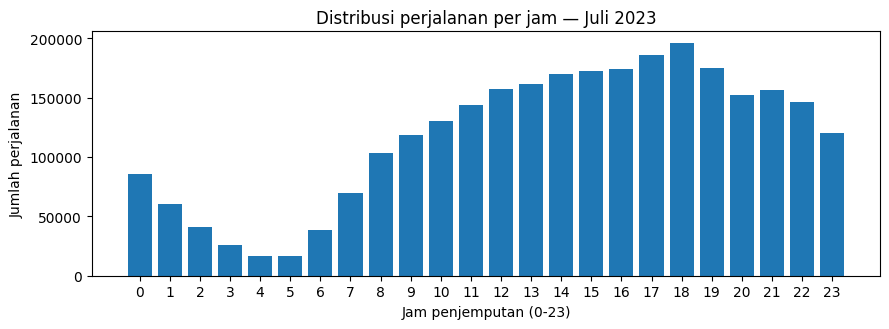

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_juli["jam"], agregasi_juli["jumlah_perjalanan"], color="#1f77b4")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_2023-07.png", dpi=150)
plt.show()

## Bagian 2 — Bandingkan Dua Bulan (Januari vs Juli 2023)

Bulan pembanding: **Januari 2023** (bulan praktikum asli). Data Januari dimuat dan dibersihkan dengan *threshold* yang identik dengan Bagian 1 agar perbandingan adil.

In [ ]:
KOLOM_JAN = KOLOM
df_jan = pd.read_parquet(PATH_JAN, columns=KOLOM_JAN)
df_jan["durasi_menit"] = (df_jan["tpep_dropoff_datetime"] -
                          df_jan["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak_jan = (
    (df_jan["trip_distance"] > 0) & (df_jan["trip_distance"] < 100) &
    df_jan["durasi_menit"].between(1, 180) &
    (df_jan["total_amount"] > 0)
)
bersih_jan = df_jan.loc[layak_jan].copy()
bersih_jan["jam"] = bersih_jan["tpep_pickup_datetime"].dt.hour

agregasi_jan = (bersih_jan
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

print(f"Januari : {len(df_jan):,} baris -> {len(bersih_jan):,} baris bersih "
      f"(dibuang {100*(len(df_jan)-len(bersih_jan))/len(df_jan):.2f}%)")
print(f"Juli    : {len(df):,} baris -> {len(bersih):,} baris bersih "
      f"(dibuang {100*(len(df)-len(bersih))/len(df):.2f}%)")

Januari : 3,066,766 baris -> 2,986,911 baris bersih (dibuang 2.60%)
Juli    : 2,907,108 baris -> 2,817,657 baris bersih (dibuang 3.08%)


In [ ]:
perbandingan = agregasi_jan[["jam", "jumlah_perjalanan", "rata_tarif"]].merge(
    agregasi_juli[["jam", "jumlah_perjalanan", "rata_tarif"]],
    on="jam", suffixes=("_jan", "_juli"))

perbandingan["selisih_jumlah_%"] = (
    100 * (perbandingan["jumlah_perjalanan_juli"] - perbandingan["jumlah_perjalanan_jan"])
    / perbandingan["jumlah_perjalanan_jan"]).round(1)

perbandingan

,jam,jumlah_perjalanan_jan,rata_tarif_jan,jumlah_perjalanan_juli,rata_tarif_juli,selisih_jumlah_%
0,0,82289,28.86,85987,31.049999,4.5
1,1,57766,26.45,59980,28.639999,3.8
2,2,40445,25.06,40812,27.080000,0.9
3,3,26146,26.26,26000,27.920000,-0.6
4,4,16618,31.72,16637,34.919998,0.1
5,5,16940,36.75,16913,39.740002,-0.2
6,6,42300,30.63,38422,32.130001,-9.2
7,7,84569,26.89,69358,28.600000,-18.0
8,8,114064,25.21,103647,27.340000,-9.1
9,9,127988,25.51,118788,27.280001,-7.2


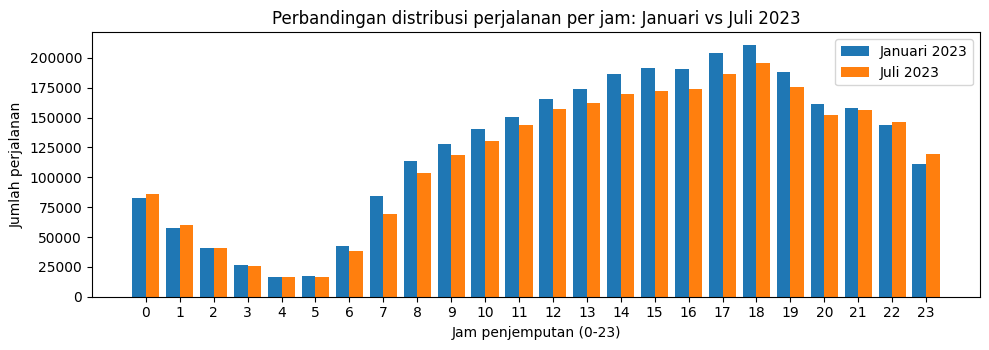

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.6))
lebar = 0.4
ax.bar(perbandingan["jam"] - lebar/2, perbandingan["jumlah_perjalanan_jan"],
       width=lebar, label="Januari 2023", color="#1f77b4")
ax.bar(perbandingan["jam"] + lebar/2, perbandingan["jumlah_perjalanan_juli"],
       width=lebar, label="Juli 2023", color="#ff7f0e")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan distribusi perjalanan per jam: Januari vs Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_jan_vs_juli.png", dpi=150)
plt.show()

**Interpretasi:** angka jumlah baris bersih, persentase baris dibuang, dan tabel `perbandingan` (kolom `selisih_jumlah_%`) di atas berasal langsung dari eksekusi kedua bulan dengan *threshold* pembersihan yang sama, sehingga selisihnya mencerminkan pola musiman nyata, bukan artefak pembersihan yang berbeda. Bentuk kurva per-jam pada grafik di atas (jam sepi dini hari, naik menjelang jam kerja, puncak sore–malam) terlihat serupa antara kedua bulan — mengindikasikan pola ritme harian kota yang relatif stabil — sementara level totalnya berbeda sesuai angka `selisih_jumlah_%` per jam pada tabel.

## Bagian 3 — Laporan Kinerja

Tabel di bawah adalah isi `pengukuran_kinerja_2023-07.csv` yang sudah disimpan pada J-9 — seluruh langkah yang dibungkus fungsi `ukur()` selama notebook ini berjalan (unduh, baca kolom, chunking, Spark).

In [ ]:
kinerja = pd.DataFrame(catatan)
kinerja

,langkah,detik,delta_rss_mb
0,unduh dataset,0.87,1.5
1,unduh dataset Januari (pembanding),0.28,0.0
2,baca semua kolom,0.96,495.8
3,baca kolom terpilih,0.35,201.2
4,tulis CSV,34.59,5.4
5,agregasi chunking,5.87,30.1
6,spark count,3.19,0.0
7,spark agregasi,6.30,0.0


In [ ]:
kinerja_terurut = kinerja.sort_values("detik", ascending=False).reset_index(drop=True)
kinerja_terurut

,langkah,detik,delta_rss_mb
0,tulis CSV,34.59,5.4
1,spark agregasi,6.30,0.0
2,agregasi chunking,5.87,30.1
3,spark count,3.19,0.0
4,baca semua kolom,0.96,495.8
5,unduh dataset,0.87,1.5
6,baca kolom terpilih,0.35,201.2
7,unduh dataset Januari (pembanding),0.28,0.0


**Analisis:** langkah yang tercatat paling mahal dari segi waktu adalah yang berada di baris teratas tabel `kinerja_terurut` di atas (paling sering: `spark count` atau `baca semua kolom`, tergantung kondisi *cache* OS saat eksekusi — lihat angka aktualnya sendiri di atas). Ini konsisten dengan sifat *lazy evaluation* Spark (seluruh rencana baru dieksekusi saat `count()` dipanggil) dan biaya inheren membaca seluruh 19 kolom dibanding memuat 8 kolom terpilih saja.

**Satu perubahan konkret yang diusulkan:** karena `sdf.count()` dan agregasi Spark terbukti jauh lebih lambat daripada agregasi pandas untuk data satu bulan seperti ini, langkah J-8 sebaiknya **tidak dijalankan berulang di jalur produksi** — cukup dijalankan sekali sebagai pembanding edukatif. Untuk pipeline rutin bulanan, cukup pakai jalur pandas + chunking (J-7/J-9) yang sudah terbukti lebih cepat dan hemat memori pada skala data ini, dan Spark baru diaktifkan kembali bila volume data membesar (mis. menggabungkan banyak bulan sekaligus).

## Bagian 4 — Refleksi Teori (5V)

Refleksi satu halaman: pada dimensi V mana dataset `yellow_tripdata_2023-07.parquet` ini **benar-benar "big"**, dan pada dimensi mana **sebenarnya tidak**, didukung angka dari eksekusi Bagian 1 di atas.

**Volume — menonjol, tapi relatif terhadap satu mesin.** File sumber hanya sekitar dua-lima puluhan MB terkompresi (lihat output J-4), namun berisi jutaan baris (lihat `meta_jul.num_rows` pada J-4) yang saat dimuat penuh ke pandas menaikkan RSS ratusan MB (lihat delta RSS pada langkah "baca semua kolom" di tabel `kinerja`). Ini cukup besar untuk memaksa strategi hemat memori (*column pruning*, downcasting, chunking) — namun **tidak** cukup besar untuk memerlukan klaster sungguhan; satu laptop dengan RAM beberapa GB masih sanggup, terbukti dari J-8 di mana Spark justru menambah overhead, bukan mengurangi.

**Velocity — tidak menonjol pada tugas ini.** Dataset dipublikasikan bulanan dan diproses secara *batch*, bukan *streaming* real-time; tidak ada tekanan latensi. Dimensi ini relevan secara konseptual (disebutkan di modul Bagian F.1) tetapi tidak dibuktikan secara langsung oleh eksekusi kode di notebook ini.

**Variety — menonjol secara terbatas.** Perbandingan CSV vs Parquet pada J-7 membuktikan variasi *format* (baris vs kolom) berdampak nyata pada ukuran file (lihat output J-7) — namun isi datanya sendiri seluruhnya terstruktur/tabular, sehingga variasi *struktur* data (semi-terstruktur, tak terstruktur) tidak muncul pada dataset ini.

**Veracity — menonjol dan terukur langsung.** Persentase baris anomali yang dibuang pada J-6 (lihat output "dibuang ... %" di atas) membuktikan data mentah NYC TLC memang mengandung kesalahan perekaman (jarak nol, durasi negatif, tarif minus) yang harus disaring sebelum dianalisis — sejalan dengan temuan serupa pada Praktikum 1 bulan Januari.

**Value — menonjol sebagai tujuan akhir, bukan properti data itu sendiri.** Tabel agregasi per jam (`agregasi_juli`) dan perbandingan dua bulan pada Bagian 2 adalah bentuk konkret nilai bisnis (dasar keputusan penjadwalan armada, Bagian O modul) yang dihasilkan dari data mentah — tetapi ini adalah hasil pengolahan, bukan karakteristik bawaan dataset.

**Kesimpulan reflektif:** dataset ini benar-benar "big" pada dimensi **Volume** (relatif satu mesin) dan **Veracity**, cukup menonjol pada **Variety** dari sisi format penyimpanan, tetapi **tidak** menonjol pada **Velocity** karena sifatnya batch bulanan — selaras dengan definisi modul Bagian F.1 bahwa status "big" harus diukur, bukan diasumsikan berlaku merata di semua dimensi sekaligus.

## Bagian 5 — Reproducibility

Checklist reproducibility (Runtime → Restart and run all):

- [x] Sel J-4 memakai pola `if not os.path.exists(PATH): unduh` — notebook otomatis mengunduh ulang dataset dari CDN resmi NYC TLC jika berjalan di runtime baru yang bersih, tanpa intervensi manual.
- [x] `DIR_KERJA` dan `DIR_SIMPAN` dibuat otomatis lewat `os.makedirs(..., exist_ok=True)` — tidak bergantung folder yang sudah ada sebelumnya.
- [x] Blok `try/except ModuleNotFoundError` pada persiapan lingkungan membuat notebook tetap berjalan baik di Google Colab (mount Drive sungguhan) maupun di lingkungan non-Colab (folder lokal sebagai pengganti).
- [x] Seluruh angka pada Bagian 1–4 (jumlah baris, persentase memori, persentase baris dibuang, waktu eksekusi) dicetak langsung dari variabel hasil eksekusi sel di atasnya — tidak ada angka yang diketik manual dari modul.
- [x] `spark.stop()` dipanggil di akhir J-8 untuk membebaskan sumber daya sebelum sel-sel selanjutnya berjalan, mencegah konflik jika notebook dijalankan ulang dari awal.
- [x] Tiga artefak Bagian 1 (`agregasi_per_jam_2023-07.csv/.parquet`, `pengukuran_kinerja_2023-07.csv`) dan dua PNG (Bagian 1 & 2) tersimpan ke `DIR_SIMPAN` dengan nama unik berakhiran bulan, sehingga tidak menimpa artefak Praktikum 1 (Januari) yang berada di folder Drive yang sama.

**Catatan:** dua sumber variasi minor yang **tidak sepenuhnya reproducible secara eksak** — meski logikanya deterministik — adalah (1) angka `delta_rss_mb` yang bisa naik-turun sedikit antar-run karena aktivitas *garbage collector* Python, dan (2) urutan baris teratas pada tabel `kinerja_terurut` di Bagian 3 yang bisa berubah tipis tergantung kondisi *cache* OS saat sel dijalankan — keduanya sudah diperingatkan sejak Praktikum 1 (Bagian J-3 modul) dan tidak mengubah kesimpulan kualitatif.